# MSE802 Assessment 2 — Task 3: Quantum Tic-Tac-Toe

**Course:** MSE802 Quantum Computing

**Runtime:** local Python 3.11 / Qiskit Aer

This notebook is a local-Jupyter adaptation of the course-supplied
`Quantum_Tic_Tac_Toe__AS2.ipynb`. The original Google Colab dependency is
removed; the completed game uses standard `ipywidgets` and testable project
code. See `SOURCE_NOTE.md` for the adaptation boundary.

## 1. Environment and local imports

The assessment starter installed packages inside Colab and used
`google.colab.widgets.Grid`. This version relies on the locked project
environment and portable `ipywidgets` components.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "Task_3_Quantum_Tic_Tac_Toe":
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from IPython.display import display
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")
print(f"Project root: {ROOT}")

Qiskit version: 2.5.1
Project root: D:\workshop\Codex\802-Quantum-Computing


## 2. Starter-code gap map

The supplied notebook left four gate operations, the eight winning triples,
and a reliable two-cell SWAP selection flow incomplete. Its board rendering
also depended on a Colab-only grid widget. The following sections complete
those items while keeping the starter's central idea: each move appends a
quantum gate and a one-shot measurement resolves the board.

## 3. Completed game model

The model lives in `mse802.tictactoe` so it can be tested independently of the
interface. Each square begins in

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}.$$

The four moves append these gates:

- **O:** $R_Y(-\pi/2)|+\rangle=|0\rangle$;
- **X:** $R_Y(+\pi/2)|+\rangle=|1\rangle$;
- **Not:** Pauli-$X$, interchanging the $|0\rangle$ and $|1\rangle$
  amplitudes; and
- **SWAP:** exchanges the complete states of two selected qubits.

The labels O = measured 0 and X = measured 1 follow the supplied comments
“rotation toward $|0\rangle$” and “rotation toward $|1\rangle$”.

Recorded moves:
{'operation': 'O', 'cell': 0, 'other_cell': None}
{'operation': 'X', 'cell': 1, 'other_cell': None}
{'operation': 'Not', 'cell': 2, 'other_cell': None}
{'operation': 'SWAP', 'cell': 0, 'other_cell': 1}


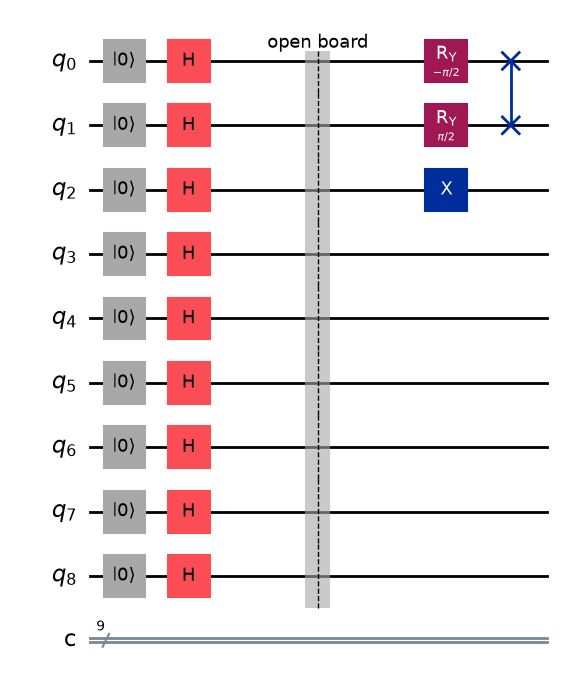

In [2]:
from mse802.tictactoe import Board

gate_demo = Board()
gate_demo.apply_move("O", 0)
gate_demo.apply_move("X", 1)
gate_demo.apply_move("Not", 2)
gate_demo.apply_move("SWAP", 0, 1)

print("Recorded moves:")
for move in gate_demo.move_log():
    print(move)
display(gate_demo.circuit.draw("mpl", fold=30))

### Measurement, bit order, and winning lines

The eight winning triples are three rows, three columns, and two diagonals.
Aer returns a nine-character string in classical-bit order
$c_8c_7\ldots c_0$, so it must be reversed before character 0 is assigned to
board cell 0. A measured 0 is O and a measured 1 is X.

Measurement is appended only to a copy of the move circuit. This preserves the
unmeasured circuit for inspection. `reset()` creates an entirely new circuit,
re-prepares all nine $|+\rangle$ states, and clears scores and history.

In [3]:
from mse802.tictactoe import WINNING_LINES

deterministic_row = Board()
for cell in range(9):
    deterministic_row.apply_move("O" if cell < 3 else "X", cell)

row_result = deterministic_row.measure(seed=802)
print("Winning triples:", WINNING_LINES)
print("Qiskit c8...c0:", row_result.qiskit_bitstring)
print("Board cells 0...8:", row_result.board)
print(f"X wins: {row_result.wins_x}; O wins: {row_result.wins_o}")

assert row_result.board == ("O", "O", "O", "X", "X", "X", "X", "X", "X")
assert (row_result.wins_x, row_result.wins_o) == (2, 1)
assert len(WINNING_LINES) == 8
print("Deterministic rule checks: PASS")

Winning triples: ((0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6))
Qiskit c8...c0: 111111000
Board cells 0...8: ('O', 'O', 'O', 'X', 'X', 'X', 'X', 'X', 'X')
X wins: 2; O wins: 1
Deterministic rule checks: PASS


## 4. Local interactive game

Select **Not**, **O**, or **X**, then click a cell. For **SWAP**, select two
different cells. **Measure** resolves all nine qubits in one shot and counts
every completed winning line; **Replay** creates a fresh board.

The interface uses `ipywidgets.GridBox`, so it works in local JupyterLab and is
not tied to Google Colab. The circuit shown under the controls is the true game
state; text on a cell is only a readable move log until measurement.

In [4]:
from mse802.tictactoe_ui import TicTacToeWidget

game = TicTacToeWidget()
display(game.widget)

## 5. Reproducible game evidence

Four games were executed with recorded simulator seeds. Games 1–3 use
deterministic rotations to make the intended gate effects independently
checkable. Game 4 leaves all cells in $|+\rangle$, so its single-shot board is
a seeded sample rather than a predetermined answer.

- Game 1 demonstrates direct O/X rotations and simultaneous winning lines.
- Game 2 prepares O everywhere, then uses Not on cells 0, 4, and 8 to create an
  X diagonal.
- Game 3 uses SWAP to exchange cells 0 and 1, then Not to complete an X row.
- Game 4 demonstrates genuine unresolved measurement randomness.

The JSON file stores seeds, complete move histories, bitstrings, resolved
boards, scores, circuit depths, and operation counts. Each measured circuit is
also retained as QASM and PNG.

**Figure 1.** Four seeded game outcomes used as reproducible evidence.

Game 1 — direct O/X rotations => OOOXXXXXX (X wins=2, O wins=1)
Game 2 — Not creates X diagonal => XOOOXOOOX (X wins=1, O wins=0)
Game 3 — SWAP and Not => XXXOOOOOO (X wins=1, O wins=2)
Game 4 — unresolved |+⟩ board => OOOXOXOOX (X wins=0, O wins=3)


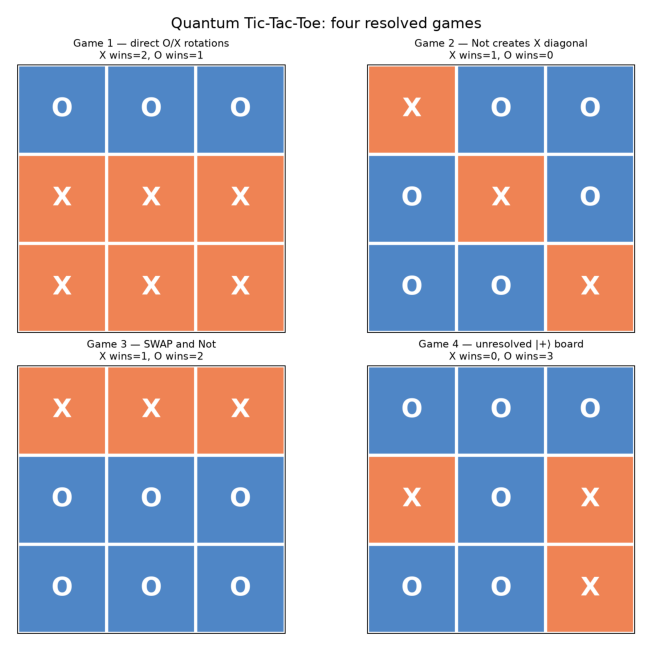

In [5]:
import json

task3_dir = ROOT / "submission" / "Task_3_Quantum_Tic_Tac_Toe"
evidence = json.loads((task3_dir / "task3_game_evidence.json").read_text())

for record in evidence["games"]:
    result = record["result"]
    print(
        record["title"],
        "=>",
        "".join(result["board"]),
        f"(X wins={result['wins_x']}, O wins={result['wins_o']})",
    )

plt.figure(figsize=(9.2, 8.2))
plt.imshow(plt.imread(task3_dir / "task3_four_game_summary.png"))
plt.axis("off")
plt.show()

### Evidence interpretation

The first three results match their analytically deterministic preparations,
including Not and SWAP effects. The fourth result must not be interpreted as a
repeatable strategy: each untouched $|+\rangle$ cell has equal O/X
probability, and the saved seed only makes this submitted run reproducible.
Counting all completed lines means one board may correctly report more than one
win. These observations confirm that the circuit—not the pre-measurement text
labels—is the authoritative game state.

## 6. Conclusion

The completed game implements all four required quantum moves, the eight
winning lines, one-shot board measurement, score counting, replay, and a
portable local interface. Deterministic preparations verify O, X, Not, and
SWAP behaviour; the seeded open-board example separately demonstrates genuine
measurement randomness. The model, interface, automated tests, QASM circuits,
JSON records, and visual summary together make the implementation reviewable
and reproducible.

## References

[1] MSE802 Quantum Computing, “Quantum Tic-Tac-Toe assessment starter notebook,” course material, 2026.

[2] IBM Quantum, “Bit ordering in Qiskit,” 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering (accessed 24 July 2026).

[3] IBM Quantum, “Quantum circuit model,” 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/api/qiskit/circuit (accessed 24 July 2026).

[4] Qiskit Aer, “AerSimulator,” 2026. [Online]. Available: https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html (accessed 24 July 2026).